# LSTM with GloVe 6B 100d

This notebook trains a LSTM model to classify a news article into one of five bias labels using GloVe embeddings for each word in each article. 

## Import

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader           

from collections import Counter
from itertools import cycle
from tqdm.auto import tqdm

from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, make_scorer, f1_score, accuracy_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.utils.class_weight import compute_class_weight

import skorch
from skorch import NeuralNetClassifier
from skorch.dataset import ValidSplit
from skorch.callbacks import LRScheduler, EarlyStopping, EpochScoring
from skorch.helper import predefined_split

from functools import partial

# Device setup
if torch.backends.mps.is_available():
    device = 'mps'
elif torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'

glove_file = 'glove.6B/glove.6B.100d.txt'
if not os.path.exists(glove_file):
    raise FileNotFoundError(f"{glove_file} not found. Please download it from https://nlp.stanford.edu/projects/glove/ and place it in your working directory.")

/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


We chose GloVe over word2vec as the pretrained model has larger vocab more robust, more reasons why here, over us training our own word2vec embedding with our limited sample of n<5000 

we chose the 6B model with 100 dimensions as we are running our models on local and our compute power is limited. 

In [2]:
# Load preprocessed data
train = pd.read_csv('transformers_train_preprocessed.csv')
test = pd.read_csv('transformers_test_preprocessed.csv')

train['cleaned_text'] = train['cleaned_text'].astype(str)
test['cleaned_text'] = test['cleaned_text'].astype(str)

# Encode labels
y_train_raw = train['Bias']
y_test_raw = test['Bias']
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_raw)
y_test = label_encoder.transform(y_test_raw)

num_classes = len(label_encoder.classes_)
print("Number of classes:", num_classes)

Number of classes: 5


In [3]:
# check 
train.head(5)

,Title,Link,Text,Source,Bias,special_symbol_length,special_symbol_proportion,cleaned_text,Text_length
0,Reminder: Trump is a demented criminal president,https://www.alternet.org/alternet-exclusives/t...,,Alternet,left,0,0.0,,20
1,Hamas Frees 4 Israeli Soldiers As Part Of Gaza...,https://www.huffpost.com/entry/hamas-frees-4-i...,"TEL AVIV, Israel (AP) - Four female Israeli so...",Huffpost,left,0,0.0,TEL AVIV Israel AP Four female Israeli soldie...,7627
2,These Progressives Will Guide Us Through the D...,https://www.thenation.com/article/society/2024...,"Without a doubt, 2025 is going to be tough-but...",TheNation,left,0,0.0,Without a doubt is going to be toughbut these...,19830
3,'It's a free country' - but some White House s...,https://www.alternet.org/white-house-staffers-...,White House staffers in the Office of Legislat...,Alternet,left,0,0.0,White House staffers in the Office of Legislat...,1604
4,VIDEO: 'Crazy' Winter Storm Forces Georgia Dri...,https://www.breitbart.com/weather/2025/01/24/v...,"A winter storm that hit the Atlanta, Georgia, ...",BreitBart,right,0,0.0,A winter storm that hit the Atlanta Georgia ar...,2144


## Global Variables

In [4]:
batch_size = 32
criterion = nn.CrossEntropyLoss()
torch.manual_seed(42)
np.random.seed(42)

## Build Vocab and Embeddings

In [5]:
def tokenize(text):
    return text.lower().split()
    
def build_vocab(texts):
    vocab = Counter()
    for text in texts:
        tokens = tokenize(text)
        vocab.update(tokens)
    return vocab

def load_glove_embeddings(glove_file, vocab, embedding_dim):
    embeddings_index = {}
    with open(glove_file, 'r', encoding='utf8') as f:
        for line in f:
            parts = line.strip().split()
            # skip any malformed lines
            if len(parts) != embedding_dim + 1:
                continue
            word = parts[0]
            vector = np.asarray(parts[1:], dtype=np.float32)
            embeddings_index[word] = vector

    # Special tokens
    word2idx = {'<PAD>': 0, '<UNK>': 1}
    pad_vec = np.zeros(embedding_dim, dtype=np.float32)
    unk_vec = np.random.normal(scale=0.6, size=(embedding_dim,)).astype(np.float32)

    # Build list of vectors
    embedding_list = [pad_vec, unk_vec]
    for word in sorted(vocab):
        word2idx[word] = len(word2idx)
        vec = embeddings_index.get(word)
        if vec is None:
            vec = np.random.normal(scale=0.6, size=(embedding_dim,)).astype(np.float32)
        embedding_list.append(vec)

    embedding_matrix = np.asarray(embedding_list, dtype=np.float32)  
    print("Embedding matrix shape:", embedding_matrix.shape)
    embedding_tensor = torch.from_numpy(embedding_matrix)      

    return word2idx, embedding_tensor, embeddings_index


We use simple white space tokenizer to use with GloVe which is word based to feed words sequentially into LSTM. 

In [6]:
def encode_text(texts, word2idx, max_len=100):
    encoded = []
    for text in texts:
        tokens = tokenize(text)
        idxs = [word2idx.get(token, word2idx['<UNK>']) for token in tokens]
        if len(idxs) < max_len:
            idxs += [word2idx['<PAD>']] * (max_len - len(idxs))
        else:
            idxs = idxs[:max_len]
        encoded.append(idxs)
    return torch.tensor(encoded)

In [7]:
vocab = build_vocab(train['cleaned_text'])        
embedding_dim = 100

word2idx, embedding_tensor, embeddings_index = load_glove_embeddings(glove_file, vocab, embedding_dim)

# check embedding match:
idx = word2idx.get('trump')
# check loaded embedding tensor directly
print("Loaded embedding tensor first 5 dims:", embedding_tensor[idx][:5])
# compare with original GloVe
print("Original GloVe vector first 5 dims:", embeddings_index['trump'][:5])

Embedding matrix shape: (37516, 100)
Loaded embedding tensor first 5 dims: tensor([-0.1573, -0.7550,  0.3684, -0.1896, -0.1690])
Original GloVe vector first 5 dims: [-0.15731 -0.75503  0.36845 -0.18958 -0.16896]


In [8]:
max_len = 100  # maximum number of tokens per article

# Encode texts to fixed‑length index tensors
X_train = encode_text(train['cleaned_text'], word2idx, max_len)
X_test = encode_text(test['cleaned_text'], word2idx, max_len)

# Convert label arrays to torch tensors
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

class EncodedTextDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.encodings[idx], self.labels[idx] 

# Create dataset instances
train_dataset = EncodedTextDataset(X_train, y_train_tensor)
test_dataset = EncodedTextDataset(X_test, y_test_tensor)

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")


Train batches: 55 | Test batches: 14


## LSTM

In [9]:
class LSTMModule(nn.Module):
    def __init__(self,
                 embedding_tensor,
                 hidden_dim=128,
                 num_layers=1,
                 bidirectional=False,
                 dropout=0.3,
                 num_classes=5):            
        super().__init__()
        self.bidirectional = bidirectional
        self.embedding = nn.Embedding.from_pretrained(
            embedding_tensor, freeze=True, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=embedding_tensor.size(1),
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_dim * (2 if bidirectional else 1),
                            num_classes)

    def forward(self, x):
        embedded = self.embedding(x)
        _, (h_n, _) = self.lstm(embedded)
        if self.bidirectional:
            feat = torch.cat((h_n[-2], h_n[-1]), dim=1)
        else:
            feat = h_n[-1]
        return self.fc(feat)

We do not train the GloVe embedding or SFT it for our use case by setting freeze=True and lock padding index so that padding stays at zero and cannot drift.

In [10]:
X_np = X_train.numpy()         
y_np = y_train_tensor.numpy()

In [11]:
# Handled imbalanced classes

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_np), y=y_np)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

In [12]:
#for debugging, setting this toggle to True means that the test set is included in validation set
USE_TEST_AS_VALID = False 

In [13]:
train_split = predefined_split(test_dataset) if USE_TEST_AS_VALID else ValidSplit(0.2, stratified=True)


net = NeuralNetClassifier(
    module=LSTMModule,
    module__embedding_tensor=embedding_tensor,
    criterion=partial(nn.CrossEntropyLoss, weight=class_weights_tensor),
    optimizer=torch.optim.Adam,
    lr=1e-3,
    batch_size=32,
    max_epochs=20,
    device=device,
    train_split=train_split,
    callbacks=[
        EpochScoring(scoring='f1_macro', name='valid_f1', lower_is_better=False),
        EpochScoring(scoring='accuracy', name='valid_acc', lower_is_better=False),
        LRScheduler(policy=ReduceLROnPlateau,
                    monitor='valid_f1',  
                    factor=0.5,
                    patience=5,
                    verbose=True),
        EarlyStopping(monitor='valid_f1', patience=5, lower_is_better=False)
    ],
)

### Hyperparameter Tuning

In [14]:

param_dist = {
    'module__hidden_dim':    [128, 256, 512], #same as in FFNN 
    'module__num_layers':    [1, 2],
    'module__bidirectional': [False, True],
    'module__dropout':       [0.1, 0.3, 0.5], #FFNN did not have dropout
    'lr':                    [0.0005, 0.001, 0.01], #same as in FFNN 
    'batch_size':            [16, 32, 64], #same as in FFNN 
}

scoring = {
    'f1_macro': make_scorer(f1_score, average='macro'),
    'accuracy': make_scorer(accuracy_score)
}
search = RandomizedSearchCV(
    net,
    param_distributions=param_dist,
    n_iter=25,                
    cv=3,                     # 3‑fold inner CV
    scoring='f1_macro',       
    refit=True,               # keep best_ estimator
    verbose=2,
    n_jobs=1                  
)

search.fit(X_np, y_np)        # skorch handles GPU inside each fit

Fitting 3 folds for each of 25 candidates, totalling 75 fits


/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  epoch    train_loss    valid_acc    valid_f1    valid_loss      lr     dur
-------  ------------  -----------  ----------  ------------  ------  ------
      1        1.6396       0.0858      0.0316        1.6289  0.0100  1.1018
      2        1.6392       0.1416      0.0496        1.6160  0.0100  0.5022
      3        1.6127       0.0858      0.0316        1.6130  0.0100  0.5569
      4        1.6219       0.1416      0.0496        1.6114  0.0100  0.6482
      5        1.6143       0.5064      0.1345        1.6108  0.0100  0.5958
      6        1.6170       0.5064      0.1345        1.6106  0.0100  0.5691
      7        1.6158       0.5064      0.1345        1.6109  0.0100  0.5427
      8        1.6123       0.5064      0.1345        1.6104  0.0050  0.5648
      9        1.6126       0.5064      0.1345        1.6105  0.0050  0.5492
Stopping since valid_f1 has not improved in the last 5 epochs.
[CV] END batch_size=64, lr=0.01, module__bidirectional=False, module__dropout=0.1, module_

/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  epoch    train_loss    valid_acc    valid_f1    valid_loss      lr     dur
-------  ------------  -----------  ----------  ------------  ------  ------
      1        1.6461       0.0944      0.0345        1.6248  0.0100  0.5983
      2        1.6339       0.1760      0.0599        1.6098  0.0100  0.5319
      3        1.6141       0.2961      0.1378        1.6087  0.0100  0.5649
      4        1.6146       0.0944      0.0345        1.6095  0.0100  0.5437
      5        1.6134       0.1888      0.1072        1.6090  0.0100  0.5742
      6        1.6055       0.1116      0.1045        1.6113  0.0100  0.5129
      7        1.5984       0.1116      0.0742        1.6062  0.0100  0.6205
      8        1.5887       0.2446      0.1778        1.6049  0.0050  0.5395
      9        1.5825       0.1974      0.1682        1.6077  0.0050  0.5095
     10        1.5489       0.1631      0.1726        1.6032  0.0050  0.5008
     11        1.4856       0.1674      0.1703        1.6169  0.0050  0.5067

...

/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  epoch    train_loss    valid_acc    valid_f1    valid_loss      lr     dur
-------  ------------  -----------  ----------  ------------  ------  ------
      1        1.6068       0.2479      0.2109        1.5884  0.0005  0.7054
      2        1.5485       0.4145      0.3570        1.5486  0.0005  0.7050
      3        1.4274       0.3718      0.3129        1.4982  0.0005  0.7070
      4        1.3061       0.3974      0.3619        1.4623  0.0005  0.7069
      5        1.1948       0.4274      0.3186        1.5330  0.0005  0.7068
      6        1.0943       0.4744      0.3627        1.4782  0.0005  0.7092
      7        0.9887       0.4786      0.3615        1.4879  0.0005  0.7081
      8        0.8690       0.4786      0.3616        1.5446  0.0003  0.7067
      9        0.7997       0.4915      0.3751        1.5313  0.0003  0.7095
     10        0.7452       0.5043      0.3796        1.5233  0.0003  0.7043
     11        0.6840       0.5171      0.3991        1.5758  0.0003  0.7073

/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  epoch    train_loss    valid_acc    valid_f1    valid_loss      lr     dur
-------  ------------  -----------  ----------  ------------  ------  ------
      1        1.6114       0.4229      0.2623        1.5877  0.0005  1.3164
      2        1.5493       0.3914      0.2950        1.5232  0.0005  1.0410
      3        1.4253       0.3543      0.2948        1.4595  0.0005  1.0443
      4        1.3020       0.3829      0.3299        1.4569  0.0005  1.0437
      5        1.2052       0.4057      0.3357        1.4460  0.0005  1.0446
      6        1.0943       0.4400      0.3721        1.4393  0.0005  1.0445
      7        0.9574       0.4057      0.3587        1.4597  0.0005  1.0579
      8        0.8583       0.4514      0.3782        1.5242  0.0003  1.0460
      9        0.8080       0.4971      0.4137        1.5386  0.0003  1.0409
     10        0.7295       0.4943      0.4089        1.5147  0.0003  1.0455
     11        0.6609       0.4971      0.4121        1.5580  0.0003  1.0426

RandomizedSearchCV(cv=3,
                   estimator=NeuralNetClassifier(_params_to_validate={'module__embedding_tensor'}, batch_size=32, callbacks=[<skorch.callbacks.scoring.EpochScoring object at 0x345b16270>, <skorch.callbacks.scoring.EpochScoring object at 0x320883ce0>, <skorch.callbacks.lr_scheduler.LRScheduler object at 0x345b17c50>, <skorch.callbacks.training.EarlyStopping o...
        [-0.6143, -0.0859, -0.0194,  ..., -0.1276,  0.1304,  0.1697]]), optimizer=<class 'torch.optim.adam.Adam'>, predict_nonlinearity='auto', torch_load_kwargs=None, train_split=<skorch.dataset.ValidSplit object at 0x3200dd6a0>, use_caching='auto', verbose=1, warm_start=False),
                   n_iter=25, n_jobs=1,
                   param_distributions={'batch_size': [16, 32, 64],
                                        'lr': [0.0005, 0.001, 0.01],
                                        'module__bidirectional': [False, True],
                                        'module__dropout': [0.1, 0.3, 0.5],
                                        'module__hidden_dim': [128, 256, 512],
                                        'module__num_layers': [1, 2]},
                   scoring='f1_macro', verbose=2)

In [23]:
best_net = search.best_estimator_
best_net.save_params(f_params='lstm_best.pt')
cv_df = pd.DataFrame(search.cv_results_)

best_params = search.best_params_

# build a boolean mask over each param_* column
mask = pd.Series(True, index=cv_df.index)
for key, value in best_params.items():
    mask &= (cv_df[f'param_{key}'] == value)

best_run = cv_df[mask]
#print(best_run)

In [20]:
best_run.T

,24
mean_fit_time,12.157362
std_fit_time,3.061564
mean_score_time,0.130968
std_score_time,0.006489
param_module__num_layers,2
param_module__hidden_dim,128
param_module__dropout,0.3
param_module__bidirectional,True
param_lr,0.0005
param_batch_size,64


### Train LSTM with Best Params

In [21]:
best_net.set_params(max_epochs=20)  #increase num epochs 
best_net.fit(X_train, y_train) #retrain on full set - test is now the hold out test set

Re-initializing module because the following parameters were re-set: bidirectional, dropout, embedding_tensor, hidden_dim, num_layers.
Re-initializing criterion.
Re-initializing optimizer.


/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  epoch    train_loss    valid_acc    valid_f1    valid_loss      lr     dur
-------  ------------  -----------  ----------  ------------  ------  ------
      1        1.6053       0.2200      0.1926        1.5813  0.0005  1.0750
      2        1.5330       0.4057      0.3278        1.5018  0.0005  1.0309
      3        1.4106       0.4400      0.3437        1.4414  0.0005  1.0429
      4        1.2791       0.4857      0.3872        1.4753  0.0005  1.0412
      5        1.1682       0.4771      0.3684        1.5038  0.0005  1.0608
      6        1.0905       0.4486      0.3582        1.4547  0.0005  1.0312
      7        1.0113       0.4714      0.3771        1.4540  0.0005  1.0390
      8        0.8859       0.4914      0.3947        1.5042  0.0003  1.0406
      9        0.7876       0.4629      0.3662        1.5476  0.0003  1.0372
     10        0.7058       0.4629      0.3741        1.5811  0.0003  1.0357
     11        0.6477       0.4629      0.3653        1.5599  0.0003  1.0399

<class 'skorch.classifier.NeuralNetClassifier'>[initialized](
  module_=LSTMModule(
    (embedding): Embedding(37516, 100, padding_idx=0)
    (lstm): LSTM(100, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
    (fc): Linear(in_features=256, out_features=5, bias=True)
  ),
)

## Evaluation

In [ ]:
y_pred = best_net.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')
report = classification_report(y_test, y_pred, target_names=label_encoder.classes_, digits=4)

print(f"LSTM Accuracy: {acc * 100:.2f}%")
print(f"LSTM Macro F1-score: {f1:.4f}")
print("\nClassification Report:\n", report)

LSTM Accuracy: 51.95%
LSTM Macro F1-score: 0.4033

Classification Report:
               precision    recall  f1-score   support

      center     0.2895    0.5366    0.3761        41
   lean left     0.3889    0.3443    0.3652        61
  lean right     0.3571    0.1351    0.1961        37
        left     0.7526    0.6577    0.7019       222
       right     0.3333    0.4342    0.3771        76

    accuracy                         0.5195       437
   macro avg     0.4243    0.4216    0.4033       437
weighted avg     0.5520    0.5195    0.5250       437



### Classification Report Commentary 

The LSTM achieves 51.03% accuracy and a macro F1-score of 0.3841, positioning its performance between the FFNN with TD-IDF (69.21% accuracy, 0.5775 macro F1) and the FFNN with GloVe (28.76% accuracy, 0.2796 macro F1). Unexpectedly, LSTM despite being a newer architecture, underperforms the classical method of FFNN with TD-IDF. 

### Confusion Matrices

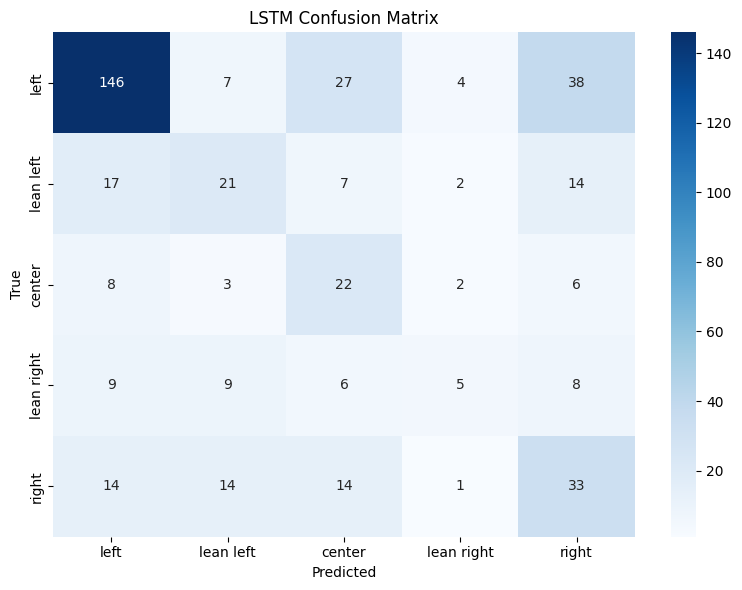

In [26]:
X_test_np = X_test.cpu().numpy()
y_test_np = y_test_tensor.cpu().numpy()
y_pred = best_net.predict(X_test_np)

# Define correct label order
label_order = ['left', 'lean left', 'center', 'lean right', 'right']
label_indices = [np.where(label_encoder.classes_ == label)[0][0] for label in label_order]

cm = confusion_matrix(y_test_np, y_pred, labels=label_indices)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_order, yticklabels=label_order)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('LSTM Confusion Matrix')
plt.tight_layout()
plt.show()

-	The LSTM performs best on the "left" class, with 160 correct predictions, showing strong recognition of the dominant class. However, precision and sensitivity are poor as seen in the over-prediction of "left", with the other classes predicting left more than their true label (with the exception of lean right). This is likely due to the unbalanced dataset despite the use of class weighting.

-	Compared to the FFNN, the LSTM shows:
	- 	Weaker boundary resolution
	- 	More confusion between ideological opposites, such as "right" being predicted as "left" and vice versa, which  is much more problematic failure than when predicting the adjacent class on the spectrum. 

In [27]:
classes = best_net.classes_ 

for i, class_label in enumerate(classes):
    y_true_binary = (y_test_np == i).astype(int)
    y_pred_binary = (y_pred == i).astype(int)

    cm = confusion_matrix(y_true_binary, y_pred_binary)
    print(f"\nOne-vs-Rest Confusion Matrix for class '{class_label}':")
    print(cm)


One-vs-Rest Confusion Matrix for class '0':
[[342  54]
 [ 19  22]]

One-vs-Rest Confusion Matrix for class '1':
[[343  33]
 [ 40  21]]

One-vs-Rest Confusion Matrix for class '2':
[[391   9]
 [ 32   5]]

One-vs-Rest Confusion Matrix for class '3':
[[167  48]
 [ 76 146]]

One-vs-Rest Confusion Matrix for class '4':
[[295  66]
 [ 43  33]]


## ROC-AUC

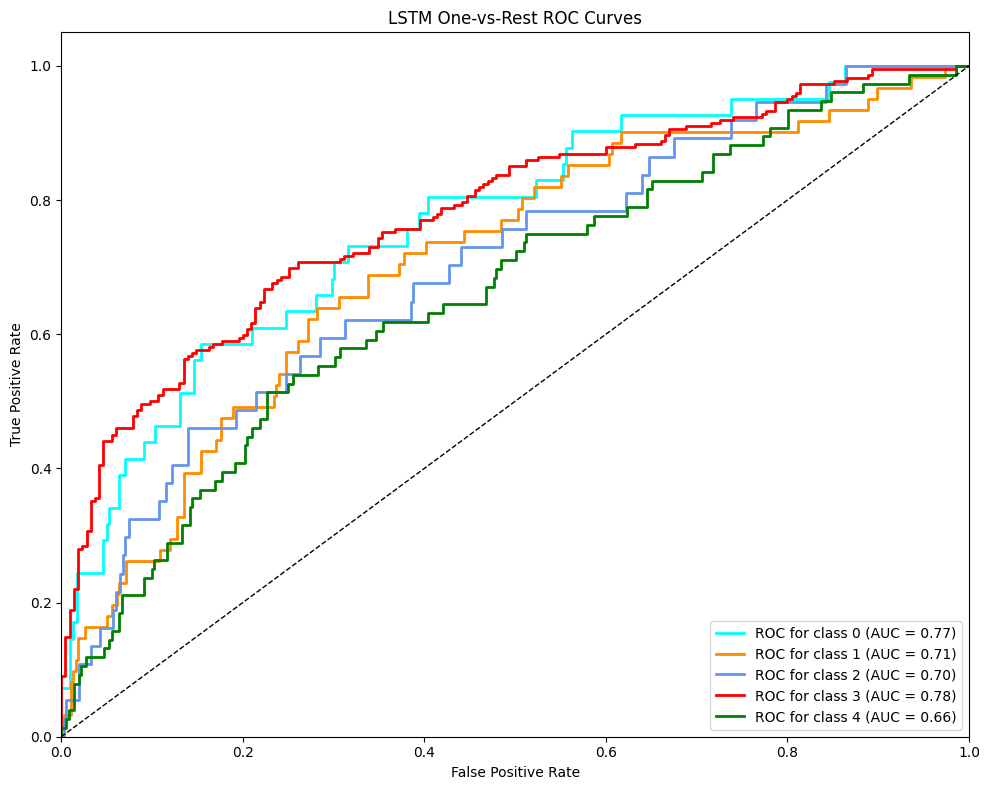

In [28]:
X_test_np = X_test.cpu().numpy()
y_test_np = y_test_tensor.cpu().numpy()
classes = best_net.classes_

y_test_binarized = label_binarize(y_test_np, classes=range(len(classes)))
y_score = best_net.predict_proba(X_test_np) 
fpr = dict()
tpr = dict()
roc_auc = dict()

for i, c in enumerate(classes):
    fpr[c], tpr[c], _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
    roc_auc[c] = roc_auc_score(y_test_binarized[:, i], y_score[:, i])

plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red', 'green', 'purple', 'brown'])

for c, color in zip(classes, colors):
    plt.plot(fpr[c], tpr[c], color=color, lw=2,
             label=f'ROC for class {c} (AUC = {roc_auc[c]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('LSTM One-vs-Rest ROC Curves')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [29]:
macro_auc = roc_auc_score(y_test_binarized, y_score, average='weighted')
print(f"Macro-average ROC AUC: {macro_auc:.4f}")

Macro-average ROC AUC: 0.7421


ROC-AUC values for the LSTM are moderate and notably lower than the FFNN across all classes:
- Left: 0.70
- Lean Left: 0.71
- Center: 0.71
- Lean Right: 0.73
- Right: 0.64

The macro-average ROC-AUC at 0.7078 is lower than for FFNN at 0.9031. These results show that the LSTM has weaker class separability, particularly for the "right" class, where the model struggles to distinguish true positives from false positives. The ROC curves indicate that the model has not learned strong decision boundaries and is likely influenced by the class imbalance.

### Performance Metrics Evaluation Summary

| Model Version | Accuracy (%) | Macro F1-score |
|---------------|--------------|----------------|
| Unweighted DT | 65.84        | 0.5658         |
| Weighted DT   | 60.22        | 0.5209         |
| Tuned DT      | 57.53        | 0.5762         |
| FFNN (TF-IDF) | 69.21        | 0.5775         |
| FFNN (GloVe)  | 28.76        | 0.2796         |
| Tuned LSTM    | 51.03        | 0.3841         |


### Final Remarks

Overall, the LSTM underperforms compared to the FFNN with TF-IDF, with lower accuracy and weaker ROC-AUC across all classes. With a small dataset size (n < 3000), FFNNs generalize faster and more reliably, while LSTMs typically require more data and longer training to reach optimal performance. 

Comparing FFNN (TF-IDF) and LSTM, the results suggest that vocabulary - as captured by TF-IDF features, is more important than the temporal patterns that LSTM models are designed to capture. 

Comparing FFNN (GloVe) and LSTM, the LSTM performs better, showing that there is some information related to the bias label that can be learnt from the sequential patterns in the data that can benefit the LSTM's architecture over a simple average of the embeddings into a flat input. 

Overall, the results show that depending on the scale of data and the problem at hand, classical methods can still outperform newer deep learning models. We now move onto transformers, with reduced confidence in our initial hypothesis that newer models will always out perform older ones. 